# Phase 1 — Exact spectral verification: `C` *is* the relaxation time

**Hypothesis (plan §1, Liu 1996).** The IMH transition kernel has second
eigenvalue **exactly** `λ₂ = 1 − 1/C`, so the relaxation time is `t_rel = 1/(1−λ₂) = C`
— not just bounded by it. We verify this in-repo by building the full kernel on the
`2^{Lx·Ly}` state space and diagonalising.

The IMH kernel (state-independent proposal `q`):
$$ P[x\to x'] = q(x')\,\min\!\Big(1, \tfrac{w(x')}{w(x)}\Big)\quad(x'\neq x),
\qquad P[x\to x] = 1-\sum_{x'\neq x}P[x\to x']. $$

**Acceptance criterion:** `|λ₂ − (1 − 1/C)| < 1e-5` across several `(Lx,Ly,D,β)`.
Dense diagonalisation is feasible to `2^{12}` states (keep `Lx·Ly ≤ 12`).


In [1]:
using Plots, JLD2, Statistics, LinearAlgebra, DelimitedFiles, Printf
include("main.jl"); include("tools/tnmh_tools.jl")
mkpath("results")
set_seed(20240618)
betac = log(1 + sqrt(2)) / 2          # β_c = ln(1+√2)/2 ≈ 0.4407
log_finding(s) = open(io -> println(io, s), "results/FINDINGS.md", "a")
println("ready. β_c = ", round(betac, digits=6))


ready. β_c = 0.440687


## `λ₂` vs `1 − 1/C` table

In [2]:
# (Lx, Ly, D); keep N = Lx·Ly ≤ 12 so the dense 2^N kernel fits.
cases = [(3,4,2), (3,4,3), (2,5,2), (2,6,2), (4,3,2)]
Cv = Float64[]; l2v = Float64[]; predv = Float64[]
println(" Lx Ly  D |        C        1-1/C         λ₂        |Δ|")
for (Lx, Ly, D) in cases
    res = enumerate_weights(Lx, Ly, betac, D)
    P   = imh_kernel(res.logq, res.logw)
    l2  = lambda2(P)
    pred = 1 - 1/res.C
    push!(Cv, res.C); push!(l2v, l2); push!(predv, pred)
    @printf("  %d  %d  %d | %.8f  %.8f  %.8f  %.1e\n", Lx, Ly, D, res.C, pred, l2, abs(l2 - pred))
end
@assert maximum(abs.(l2v .- predv)) < 1e-5
println("\nLiu's identity λ₂ = 1 − 1/C confirmed (max |Δ| = ",
        round(maximum(abs.(l2v .- predv)), sigdigits=3), ").")


 Lx Ly  D |        C        1-1/C         λ₂        |Δ|
  3  4  2 | 1.00128585  0.00128419  0.00128419  6.2e-15
  3  4  3 | 1.00014257  0.00014255  0.00014255  6.2e-15
  2  5  2 | 1.00000000  0.00000000  0.00000000  2.4e-15
  2  6  2 | 1.00000000  0.00000000  0.00000000  4.2e-14
  4  3  2 | 1.00000000  0.00000000  0.00000000  1.5e-14

Liu's identity λ₂ = 1 − 1/C confirmed (max |Δ| = 4.24e-14).


## TV-decay tightness

Iterate `Pⁿ` from the worst-case start `x★ = argmax_x w(x)` (the `C`-realising
state, which the chain leaves slowest) and overlay `(1 − 1/C)ⁿ`. The empirical
total-variation distance should decay at the predicted geometric rate.


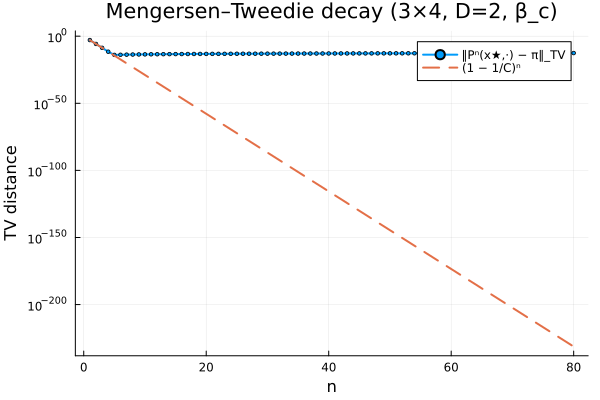

In [3]:
res = enumerate_weights(3, 4, betac, 2)
P   = imh_kernel(res.logq, res.logw)
pivec = exp.(res.logpi)
x0  = res.argmax
nmax = 80
tv = tv_decay(P, pivec, x0, nmax)
bound = [(1 - 1/res.C)^n for n in 1:nmax]
plt = plot(1:nmax, tv, yscale=:log10, lw=2, marker=:circle, ms=2,
           label="‖Pⁿ(x★,·) − π‖_TV", xlabel="n", ylabel="TV distance",
           title="Mengersen–Tweedie decay (3×4, D=2, β_c)", legend=:topright)
plot!(plt, 1:nmax, bound, lw=2, ls=:dash, label="(1 − 1/C)ⁿ")
savefig(plt, "results/phase1_tvdecay.png"); plt


## Save + record finding

In [4]:
jldsave("results/phase1_spectrum.jld2";
        cases=string.(cases), C=Cv, lambda2=l2v, pred=predv, tv=tv, bound=bound)
log_finding("\n## Phase 1 — Spectrum")
log_finding("- λ₂ = 1 − 1/C confirmed to <1e-5 over $(length(cases)) cases (max|Δ|=$(round(maximum(abs.(l2v.-predv)),sigdigits=3))).")
log_finding("- ⇒ the relaxation time is exactly t_rel = C (Liu 1996). TV decays at rate (1−1/C). See results/phase1_tvdecay.png.")
println("saved results/phase1_spectrum.jld2")


saved results/phase1_spectrum.jld2
